In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from msfm.utils import prior, parameters, files, logger, observation, scales
from msi.utils import preprocessing, plotting

In [3]:
use_flow = True

if use_flow:
    import torch
    from msi.flow_conductor.likelihood_flow import LikelihoodFlow
    from msi.flow_conductor import architecture
else:
    import tensorflow as tf
    from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
    from msi.gaussian_mixture import architecture

# v14

### lensing

In [4]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

# file_label = "8mpc"
# # file_label = "12mpc"

# n_steps = 200_000

### clustering

In [5]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_steps = 400_000

# file_label = "32mpc"

### combined

In [6]:
with_lensing = True
with_clustering = True
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_steps = 100_000
n_steps = 400_000

file_label = "8,32mpc"
# file_label += "_lmin=113"

In [7]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v14/extended"
out_dir_base = "/pscratch/sd/a/athomsen/run_files/v14/cls"

# v15

### lensing

In [8]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

# file_label = "default"

# n_steps = 300_000

### clustering

In [9]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_steps = 400_000

# file_label = "32mpc"

### combined

In [10]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_steps = 300_000

# file_label = "default"

In [11]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v15/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v15/extended"
# out_dir_base = "/pscratch/sd/a/athomsen/run_files/v15/cls"

# shared

In [12]:
n_params = len(params)
apply_log = True
standardize = False

out_dir = os.path.join(out_dir_base, "mutual_info")
if with_lensing and not with_clustering:
    out_dir = os.path.join(out_dir, "lensing")
elif with_clustering and not with_lensing:
    out_dir = os.path.join(out_dir, "clustering")
elif with_lensing and with_clustering:
    out_dir = os.path.join(out_dir, "combined")
out_dir = os.path.join(out_dir, f"standard={standardize},log={apply_log},steps={n_steps}")

pred_file = os.path.join(out_dir, file_label, "preds.h5")
print(f"pred_file = {pred_file}")

pred_file = /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/combined/standard=False,log=True,steps=300000/default/preds.h5


In [13]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v14/extended"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v14/cls"

# n_params = len(params)
# apply_log = True
# standardize = False
# pca_components = None
# # n_steps = 100_000
# # n_steps = 200_000
# # n_steps = 300_000
# # n_steps = 400_000
# cosine_decay = False

# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log=True,cosine={cosine_decay},steps={n_steps}"

# label = os.path.join(label, file_label)
# # label = os.path.join(label, "v2", file_label)
# loss = "mutual_info"

# pred_file = os.path.join(out_dir, loss, label, "preds.h5")
# print(pred_file)

In [14]:
def try_mock(f, mock):
    try:
        # pred = f[f"mocks/{mock}"][:]
        pred = f[f"mocks/pred/{mock}"][:]
        print(f"Read {mock} predictions")
        
        return pred
    except:
        print(f"There is no {mock} mock in the file")
        
with h5py.File(pred_file, "r") as f:
    grid_preds = f["grid/preds/test"][:]
    grid_cosmos = f["grid/cosmos/test"][:]
    fidu_preds = f["fidu/preds"][:]
    
    buzzard_pred = try_mock(f, "Buzzard")
    buzzard_pred_dnf = try_mock(f, "Buzzard_mocked_DNF")
    cardinal_pred = try_mock(f, "Cardinal")
    
    mice_pred = try_mock(f, "MICE")
    euclid_pred = try_mock(f, "Euclid")
    
# print(f"Read from {pred_file}")
# # new_params = ["Om", "s8", "Aia", "n_Aia", "bta"]
# # new_params = ["Om", "s8", "bg1", "bg2", "bg3", "bg4"]
# new_params = ["Om", "s8"]
# grid_cosmos = grid_cosmos[:,[params.index(param) for param in new_params]]
# params = new_params

print(grid_preds.shape)
print(grid_cosmos.shape)

There is no Buzzard mock in the file
There is no Buzzard_mocked_DNF mock in the file
There is no Cardinal mock in the file
There is no MICE mock in the file
There is no Euclid mock in the file
(200000, 20)
(200000, 10)


# normalizing flow $p(x | \theta)$

### initialization

In [15]:
# default

# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 16,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=256,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    # label=label,
    label=file_label + "_sigmoid",
    # load_existing=False,
    load_existing=True,
)

25-09-15 07:43:27 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/combined/standard=False,log=True,steps=300000/default_sigmoid/likelihood_flow 
25-09-15 07:43:27 likelihood_f INF   Initialized the normalizing flow 
25-09-15 07:43:27 likelihood_f INF   Running on device cuda with default float torch.float32 
25-09-15 07:43:27 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/combined/standard=False,log=True,steps=300000/default_sigmoid/likelihood_flow/likelihood_flow.pt 


### training

In [16]:
# # default
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [17]:
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=300,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# likelihood Flow $p(\theta|x)$

### architecture

In [18]:
# # input dimensions
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# # shared hyperparameters
# context_embedding_dim = 32

# embedding_net = architecture.get_context_embedding_net(
#     context_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     hidden_dim=64,
#     n_blocks=3,
#     dropout_probability=0.0,
#     use_batch_norm=False,
# )    

# base_dist = architecture.get_normal_dist(
#     feature_dim=theta_dim,
# )

# transform = architecture.get_sigmoids_transform(
#     feature_dim=theta_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     # hidden_dim=256,
#     hidden_dim=512,
#     svd_kwargs={},
#     sigmoids_kwargs={
#         "n_sigmoids": 32,
#         "num_blocks": 3,
#         "dropout_probability": 0.0,
#     }
# )

# model = LikelihoodFlow(
#     params, 
#     conf, 
#     embedding_net=embedding_net,
#     base_dist=base_dist,
#     transform=transform,
#     out_dir=out_dir, 
#     label=label + "_posterior",
#     # load_existing=False,
#     load_existing=True,
# )

### training

In [19]:
# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_cosmos,
#     theta=grid_preds,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# Gaussian Mixture Model

In [20]:
# layers = architecture.get_gmm_layers(
#     n_x=grid_preds.shape[-1],
#     n_theta=grid_cosmos.shape[1],
#     n_gaussians=4,
#     n_units=256,
#     n_layers=4,
#     activation="relu",
#     dropout_rate=0.1,
# )

# model = LikelihoodGMM(
#     params, 
#     conf,
#     layers=layers,
#     out_dir=out_dir, 
#     label=label,
#     load_existing=False,
# )

In [21]:
# # n_cosmos = file_dict["grid/pred"].shape[0]
# # n_examples = grid_preds.shape[0]
# # # such that GPU utilization is maximized, but not larger
# # batch_size = 8 * n_cosmos
# # print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")
# batch_size = 10_000

# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=1_000,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # schedule
#     # scheduler_kwargs={"factor": 0.75, "patience": 20, "cooldown": 10, "min_lr": 1e-6},
#     scheduler_kwargs={"factor": 0.8, "patience": 10, "cooldown": 5, "min_lr": 1e-6},
#     # scheduler_kwargs={},
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=1e-5,
#     save_model=True,
# )

### convergence tests

In [22]:
# grid_preds_sample = model.plot_diagnostics(
#     grid_preds_true=grid_preds,
#     grid_cosmos=grid_cosmos,
#     n_samples=100,
#     n_cosmos=1000,
#     do_eecp=True,
#     do_tarp=True,
#     tarp_kwargs = {"n_bootstrap": 100, "n_alpha_bins": 20}
# )

In [23]:
# # v11 and v12
# _ = model.plot_diagnostics(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=grid_cosmos,
#     n_samples=100,
#     n_cosmos=10_000,
#     do_hist=False,
#     do_dlss=False,
#     do_eecp=True,
#     do_tarp=True,
# )

In [24]:
# # this only works for v10
# unique_cosmos, inverse_indices = np.unique(grid_cosmos, axis=0, return_inverse=True)
# n_unique_cosmos = unique_cosmos.shape[0]
# n_examples_per_cosmo = int(grid_cosmos.shape[0]//n_unique_cosmos)

# grid_preds_per_cosmo = np.zeros((n_unique_cosmos, n_examples_per_cosmo, grid_preds.shape[1]))
# for i, unique_val in tqdm(enumerate(unique_cosmos)):
#     matching_indices = np.where(inverse_indices == i)[0]
#     grid_preds_per_cosmo[i, :len(matching_indices)] = grid_preds[matching_indices]

# _ = model.plot_diagnostics(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds_per_cosmo,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=unique_cosmos,
#     n_samples=100,
#     do_hist=True,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

In [25]:
# n_examples = 10_000
# _ = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=grid_preds[:n_examples,np.newaxis,:], 
#     grid_cosmos=grid_cosmos[:n_examples,:],
#     n_samples=10,
#     do_hist=False,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

# observation

CosmoGrid internal

In [26]:
# obs_dict = {}

# shift = 0
# n_examples = 15
# # n_examples = 8
# i_fidu = 0
# range_examples = range(shift, n_examples+shift)
# fidu_cosmo = {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))}

# # for i_fidu in range(n_examples):
# #     obs_dict[f"fiducial_{i_fidu}"] = {
# #         "pred": fidu_preds[i_fidu], 
# #         "point":, fidu_cosmo,
# #     }

# obs_dict[f"fiducial_mean"] = {
#     "pred": np.mean(fidu_preds, axis=0), 
#     "point": fidu_cosmo,
# }


# # obs_dict[f"fiducial_[{shift},{shift+n_examples}]_mean"] = {
# #     "pred": np.mean(fidu_preds[range_examples], axis=0), 
# #     "point": fidu_cosmo,
# # }

# # obs_dict[f"fiducial_[{shift},{shift+n_examples}]_stack"] = {
# #     "pred": fidu_preds[range_examples], 
# #     "point": fidu_cosmo,
# # }

# # mse_deviation = np.mean((fidu_preds - np.median(fidu_preds, keepdims=True, axis=0))**2, axis=-1)
# # i_opt = np.argmin(mse_deviation)
# # print(f"i_opt = {i_opt}")
# # obs_dict[f"fiducial_opt_{i_opt}"] = {
# #     "pred": fidu_preds[i_opt], 
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_stack_[{range_examples[0]}:{range_examples[-1]}]"] = {
# #     "pred": np.stack([fidu_preds[i] for i in range_examples], axis=0), 
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }


In [27]:
# mask = grid_cosmos[:,0]==0.3
# grid_preds = grid_preds[mask]
# grid_cosmos = grid_cosmos[mask]

In [28]:
# obs_dict = {}

# n_examples = 15
# i_examples = 15
# range_examples = list(range(i_examples*n_examples, (i_examples+1)*n_examples))

# # for i_fidu in range(n_examples):
# #     obs_dict[f"fiducial_{i_fidu}"] = {
# #         "pred": fidu_preds[i_fidu], 
# #         "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# #     }

# # i_opt = 9372
# # obs_dict[f"fiducial_opt_{i_opt}"] = {
# #     "pred": fidu_preds[i_opt], 
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_mean"] = {
# #     "pred": np.mean(fidu_preds[range_examples], axis=0),
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_mean_all"] = {
# #     "pred": np.mean(fidu_preds, axis=0),
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_stack_[{range_examples[0]}:{range_examples[-1]}]"] = {
# #     "pred": np.stack([fidu_preds[i] for i in range_examples], axis=0), 
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_mean"] = {
# #     "pred": np.mean(fidu_preds, axis=0),
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

# # obs_dict[f"fiducial_median"] = {
# #     "pred": np.median(fidu_preds, axis=0),
# #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
# # }

In [29]:
# # obs_dict = {}

# n_examples = 1
# i_examples = 0

# for i_grid in range(n_examples):
#     i_grid *= 80
#     obs_dict[f"grid_{i_grid}"] = {
#         "pred": grid_preds[i_grid],
#         "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
#     }

# # obs_dict[f"grid_{i_grid}_mean"] = {
# #     "pred": np.mean(grid_preds[:80], axis=0),
# #     "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
# # }

# # for i in range(5):
# # for i in range(3):
# # for i in range(200, 205):
# #     grid_selected = grid_preds[i*80:(i+1)*80]
# #     cosmos_selected = grid_cosmos[i*80:(i+1)*80]
# #     point = {str(param): value for param, value in zip(params, cosmos_selected[0])}
# #     print(i, point)
    
# #     # for j in range(n_examples):
# #     #     obs_dict[f"grid_{i},{j}"] = {
# #     #         "pred": grid_selected[j],
# #     #         "point": point,
# #     #     }
        
# #     obs_dict[f"grid_{i}_stack"] = {
# #         "pred": np.stack([grid_selected[j] for j in range(n_examples)], axis=0), 
# #         "point": point,
# #     }

# #     obs_dict[f"grid_{i}_mean"] = {
# #         "pred": np.mean(grid_selected[:n_examples], axis=0),
# #         "point": point,
# #     }

DES footprint

lensing

# buzzard_pred

In [37]:
obs_dict = {}

buzzard_indices = list(range(0, 16))
buzzard_indices.remove(1)
with h5py.File(pred_file, "r") as f:
    buzzard_stack = []
    for i in buzzard_indices:
        pred = np.squeeze(f[f"mocks/pred/Buzzard_{i}"])
        buzzard_stack.append(pred)
        print(pred)
        
        # obs_dict[f"Buzzard_{i}"] = {
        #     "pred": pred,
        #     "point": buzzard_cosmo,
        # }

buzzard_stack = np.stack(buzzard_stack, axis=0)

obs_dict[f"Buzzard_mean"] = {
    "pred": np.mean(buzzard_stack, axis=0),
    "point": buzzard_cosmo,
}

obs_dict[f"Buzzard_stack"] = {
    "pred": np.stack(buzzard_stack, axis=0),
    "point": buzzard_cosmo,
}

[ 0.06475961  0.3591548  -0.85373205 -0.608255    0.2062442   0.18119317
 -0.01399925  0.66167426 -0.06304418 -0.36684224  0.06908476 -0.15282486
  0.90339005 -0.35742518  0.35379136  0.24083012 -0.17386591 -0.11298662
 -0.35698923 -1.2430636 ]
[ 0.08549303  0.36329275 -1.0287571  -0.5772551   0.15553138  0.20721039
 -0.03812376  0.7372916  -0.14369087 -0.4387367   0.19622923 -0.17189728
  1.0113814  -0.285197    0.35194746  0.07785238 -0.1551581  -0.03459936
 -0.44955733 -1.2234465 ]
[ 0.01240957  0.38461375 -0.9787066  -0.49213284  0.24720216  0.24584009
  0.12645864  0.67793477 -0.0054054  -0.31459588  0.22368307 -0.09454709
  0.8977361  -0.23453882  0.379174    0.32065025 -0.24203853 -0.10635146
 -0.3686151  -1.2298241 ]
[ 0.10280994  0.43845832 -0.9829292  -0.5982439   0.22596315  0.15413547
  0.05241145  0.6833664  -0.17449372 -0.3136524   0.2634393  -0.26399618
  0.9064839  -0.33669993  0.36382008  0.20639174 -0.23157386  0.01054344
 -0.39896804 -1.2470598 ]
[ 0.10928363  0.4084

clustering

In [31]:
# obs_dict = {}

# # bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan, "qbg1": np.nan, "qbg2": np.nan, "qbg3": np.nan, "qbg4": np.nan}

# obs_dict["Buzzard"] = {
#     "pred": np.squeeze(buzzard_pred),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# }

# # obs_dict["Cardinal"] = {
# #     "pred": np.squeeze(cardinal_pred),
# #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# # }

In [32]:
# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# buzzard_flock_preds = []
# with h5py.File(pred_file, "r") as f:
#     for i, buzzard_flock_label in enumerate(buzzard_flock_labels):
#         buzzard = np.squeeze(f[f"mocks/{buzzard_flock_label}"])
#         buzzard_flock_preds.append(buzzard)
        
#         obs_dict[f"Buzzard_{i}"] = {
#             "pred": buzzard,
#             "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
#         }
        
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
        
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
# obs_dict["Buzzard_flock_stack"] = {
#     "pred": buzzard_flock_preds,
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# }

# buzzard_flock_mean = np.mean(buzzard_flock_preds, axis=0)
# obs_dict["Buzzard_flock_mean"] = {
#     "pred": buzzard_flock_mean,
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# }

Octant footprint

In [33]:
# obs_dict["MICE"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/MICE"]),
#     "point": {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

# obs_dict["Euclid"] = {
#     "pred": np.squeeze(file_dict["mocks/pred/Euclid"]),
#     "point": {"Om": 0.319, "s8": 0.83, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# }

### MCMC and plotting


Starting with mock observation Buzzard_mean
25-09-15 07:52:14 likelihood_f INF   Sampling the posterior from a single observation 
25-09-15 07:52:14      mcmc.py INF   Initial values in prior: 49.3% 
25-09-15 07:52:14      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:26<00:00, 38.22it/s]

25-09-15 07:52:40      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:26<00:00, 37.55it/s]

25-09-15 07:53:07      mcmc.py INF   MAP parameters: {'Om': 0.293, 's8': 0.841, 'w0': -0.724, 'Aia': 0.305, 'n_Aia': 4.401, 'bta': 1.403, 'bg1': 1.273, 'bg2': 1.395, 'bg3': 1.501, 'bg4': 1.567} 


...

  0%|          | 0/66 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:650: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


  0%|          | 0/66 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:650: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


25-09-15 08:05:41  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/combined/standard=False,log=True,steps=300000/default_sigmoid/likelihood_flow/contours_Buzzard_stack.png 


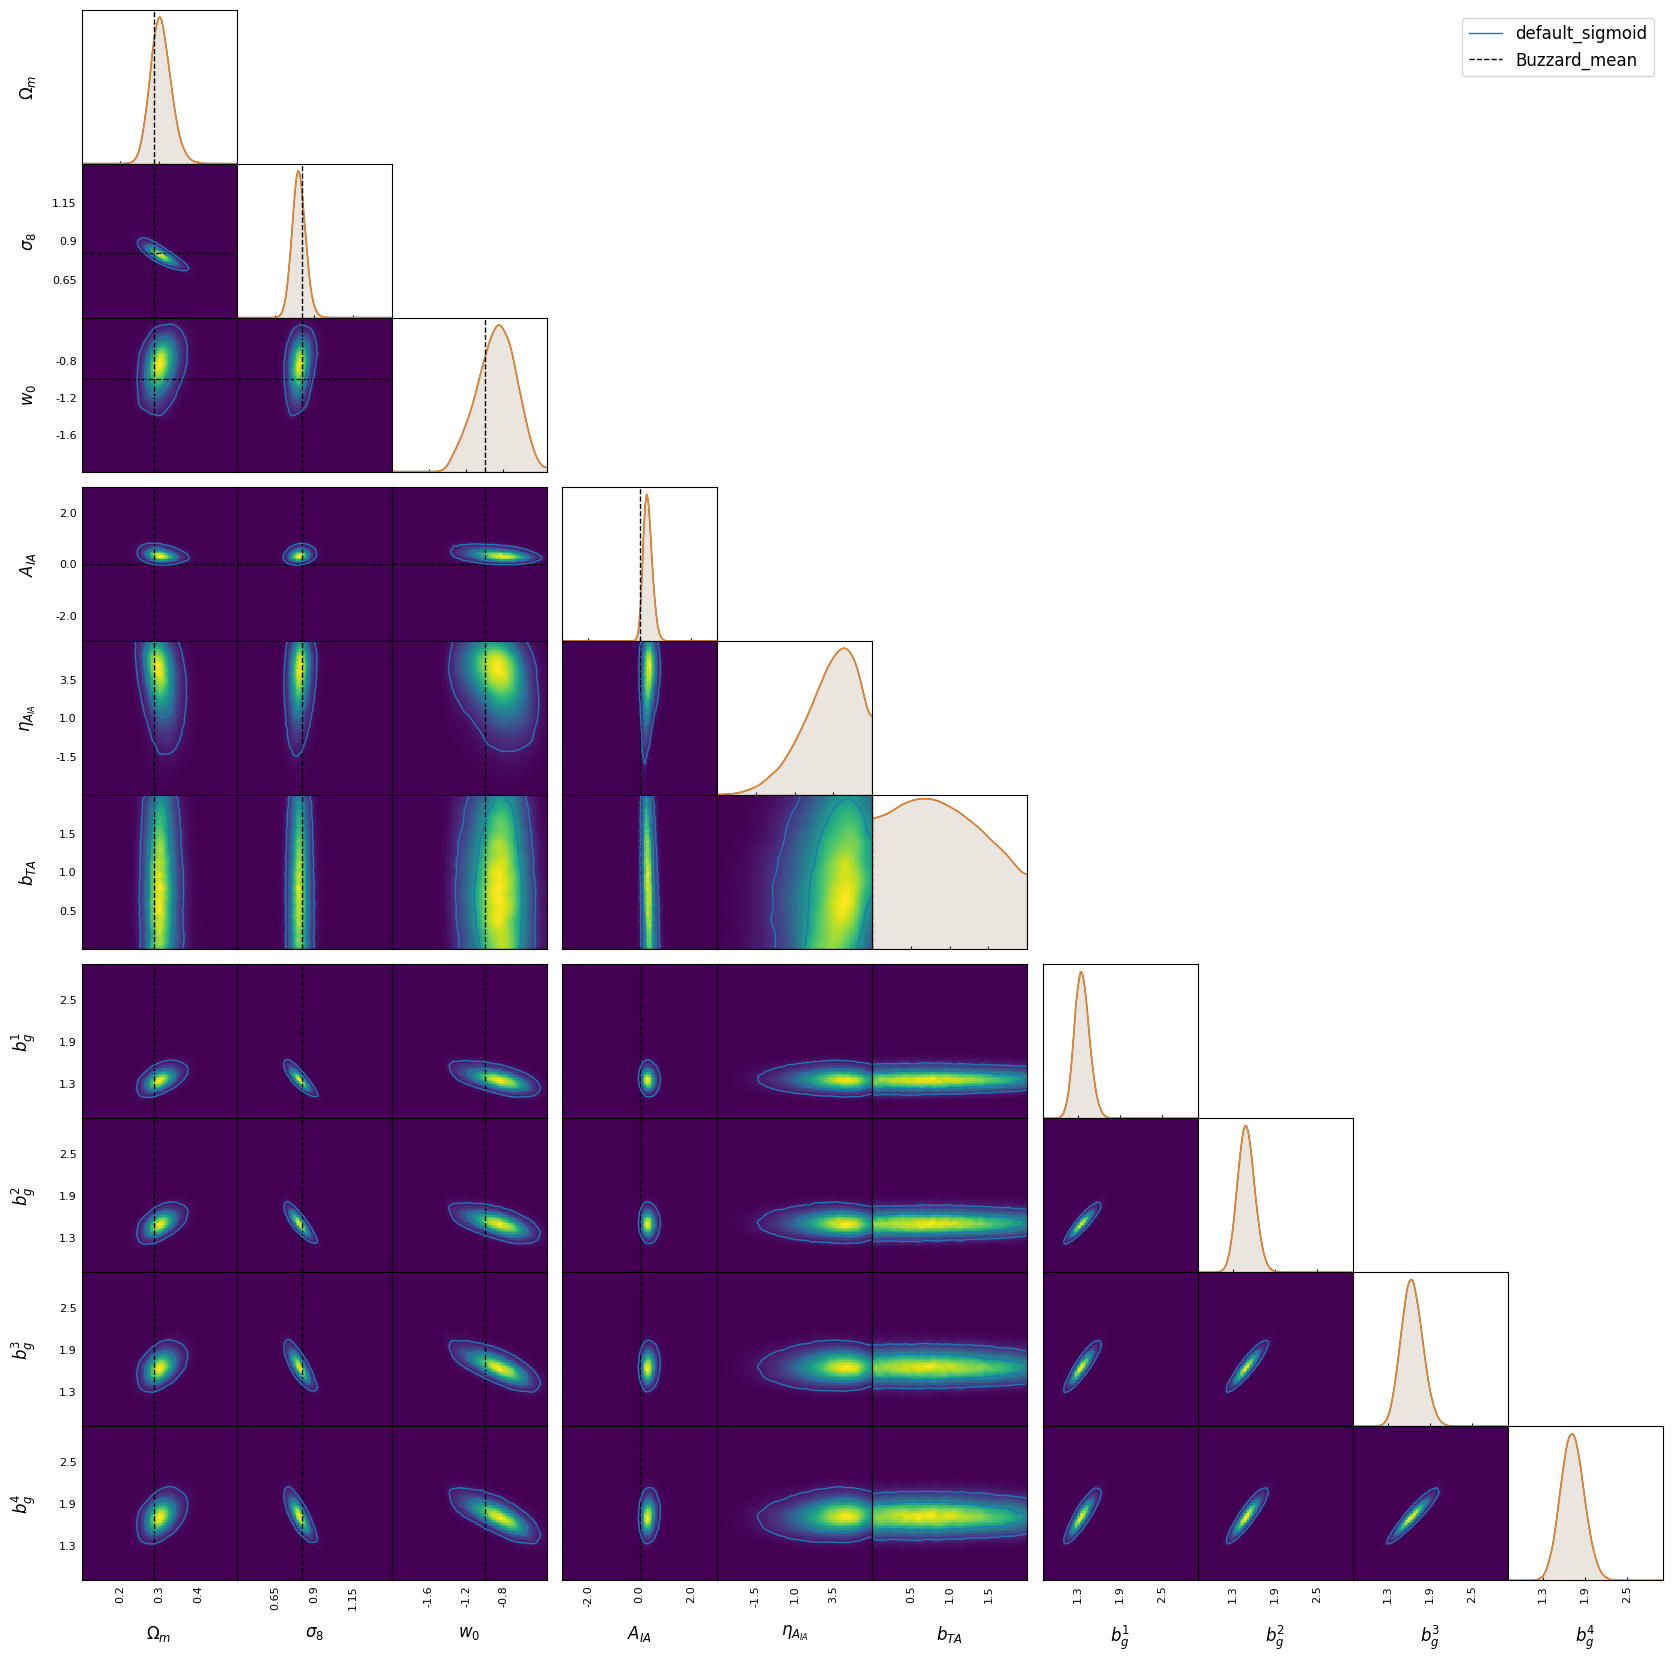

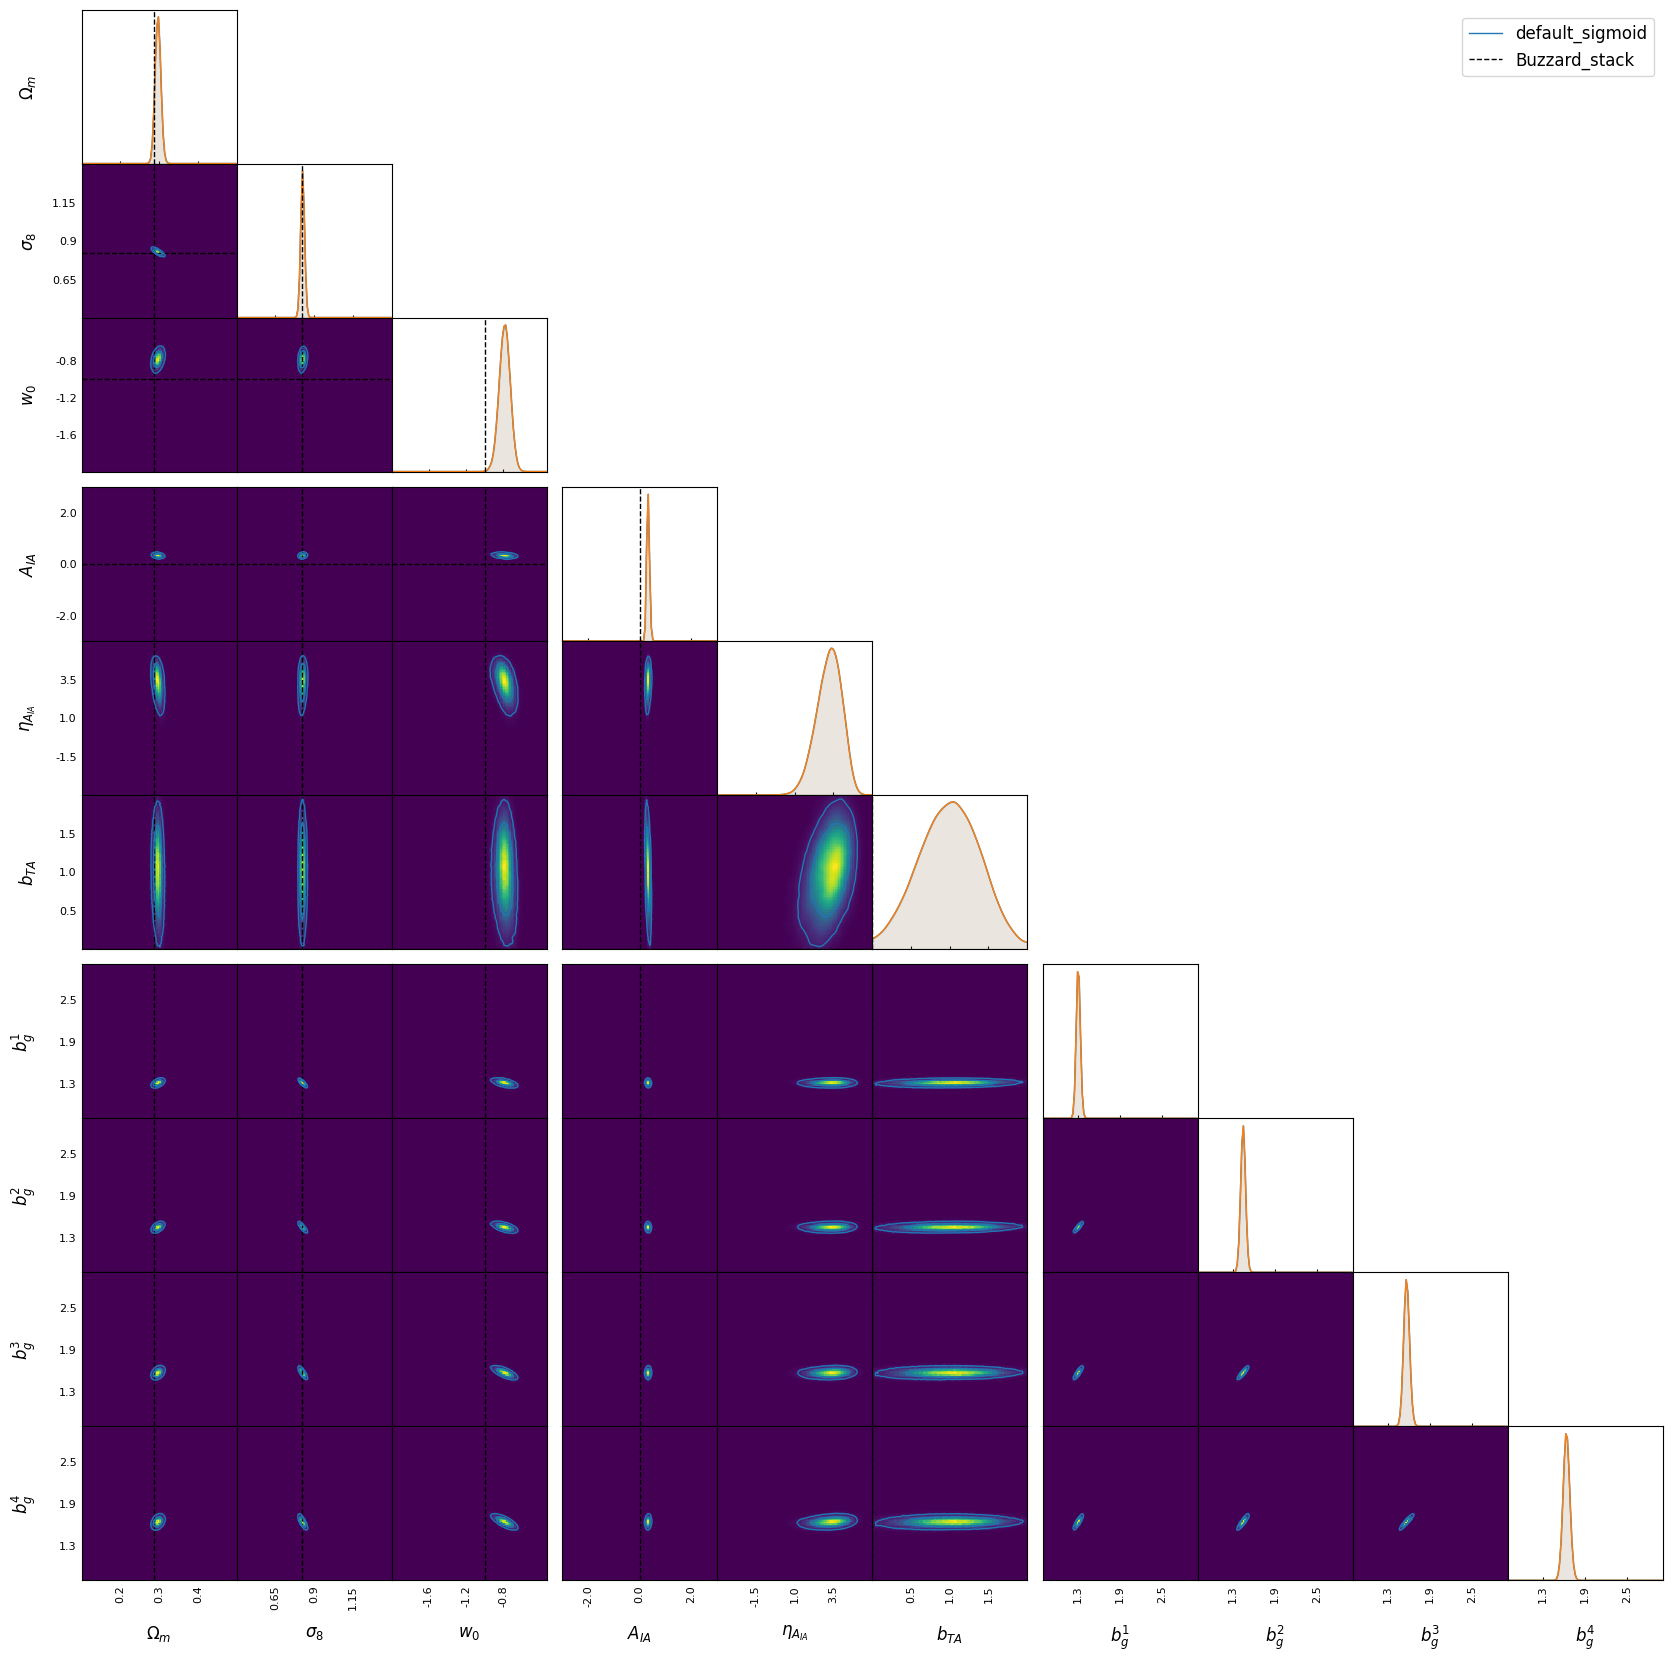

In [38]:
extra_label = ""
# extra_label = "Om=0.3"
# extra_label = f"_n{n_examples}_i{i_examples}_mocks"
# extra_label = f"_gaussian_prior_n{n_examples}_i{i_examples}_mocks"

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    # print(obs_dict[key]["pred"])
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_burnin_steps=1000,
        n_samples=1024*1000,
    )

    model.plot_contours(
        posterior_samples,
        obs_point=obs_dict[key]["point"],
        obs_label=key,
        label=key+extra_label,
        with_des_chain=False,
        density=True
    )

### sample the posterior directly

In [35]:
# extra_label = ""

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
#     # print(obs_dict[key]["pred"])
    
#     # posterior_samples = model.sample_likelihood(obs_dict[key]["pred"][np.newaxis], n_samples=10_000, batch_size=None, return_numpy=True)
#     posterior_samples = model.sample_likelihood(obs_dict[key]["pred"][np.newaxis], n_samples=100_000, batch_size=None, return_numpy=True)
#     posterior_samples = np.squeeze(posterior_samples)
    
#     plotting.plot_chains(
#         posterior_samples,
#         params=params,
#         conf=conf,
#         # cosmetics
#         title=None,
#         colors=None,
#         plot_labels="samples",
#         scale_to_prior=True,
#         group_params=False,
#         tri_kwargs={},
#         density=True,
#         # cosmo
#         plot_obs=True,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#     )
    
#     samples_file = os.path.join(model.model_dir, f"chain_{key}.npy")
#     print(samples_file)
#     np.save(samples_file, posterior_samples)

In [36]:
# extra_label = "_16_mocks"

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
#     # print(obs_dict[key]["pred"])
    
#     posterior_samples = model.sample_posterior(
#         obs_dict[key]["pred"],
#         label=key+extra_label,
#         n_walkers=1024,
#         n_burnin_steps=500,
#         n_samples=1024*500,
#     )

#     plotting.plot_chains(
#         posterior_samples,
#         params=params,
#         conf=conf,
#         # cosmetics
#         title=None,
#         colors=None,
#         plot_labels="samples",
#         scale_to_prior=True,
#         group_params=False,
#         tri_kwargs={},
#         density=True,
#         # cosmo
#         plot_obs=True,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#     )

#     # model.plot_contours(
#     #     posterior_samples,
#     #     obs_point=obs_dict[key]["point"],
#     #     obs_label=key,
#     #     label=key+extra_label,
#     #     with_des_chain=False,
#     # )

# old